# Phân tích chuyên sâu về chỉ số Insulin - Pima Indians Diabetes

Notebook này được tạo để phân tích riêng về biến `insulin` trong tập dữ liệu Pima Indians Diabetes.

Trọng tâm:
- Thống kê mô tả về biến Insulin
- Vấn đề Missing Values (insulin = 0)
- Phân bố của Insulin theo Outcome
- Mối tương quan giữa Insulin và Glucose

In [19]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [20]:
column_names = [
    "pregnancies",
    "glucose",
    "blood_pressure",
    "skin_thickness",
    "insulin",
    "bmi",
    "diabetes_pedigree_function",
    "age",
    "outcome",
]

In [21]:
repo_root = Path().resolve().parent.parent
data_path = repo_root / "Lab_03" / "data" / "pima-indians-diabetes.csv"

df = pd.read_csv(data_path, header=None, names=column_names)
df.head()


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1. Dữ liệu gốc (Bao gồm các giá trị 0)

Trong bộ dữ liệu gốc, insulin có chứa các giá trị 0. Về mặt sinh lý học đây là điều không thể. Do đó số 0 ở đây thực chất là dữ liệu bị thiếu (missing value).

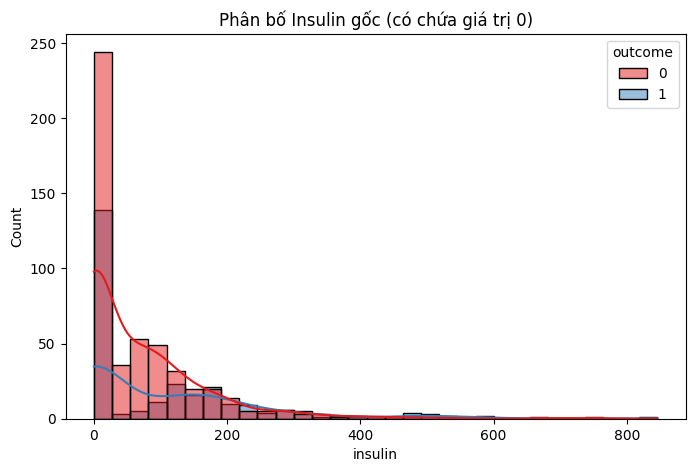

In [22]:
fig_raw, ax_raw = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=df, 
    x="insulin", 
    hue="outcome", 
    kde=True, 
    ax=ax_raw,
    palette="Set1"
)
ax_raw.set_title("Phân bố Insulin gốc (có chứa giá trị 0)")
plt.show()

In [23]:
zero_count = (df['insulin'] == 0).sum()
zero_rate = (zero_count / len(df)) * 100

print(f"Số lượng người có mức Insulin bằng 0: {zero_count} ({zero_rate:.2f}% tập dữ liệu)")
print("=> Tỷ lệ missing value quá cao, chúng ta cần thay thế giá trị 0 bằng `NaN` để phân tích chính xác.")

Số lượng người có mức Insulin bằng 0: 374 (48.70% tập dữ liệu)
=> Tỷ lệ missing value quá cao, chúng ta cần thay thế giá trị 0 bằng `NaN` để phân tích chính xác.


## 2. Dữ liệu sau khi xử lý (0 -> NaN)

In [24]:
df_masked = df.copy()
df_masked['insulin'] = df_masked['insulin'].replace(0, np.nan)

# Thống kê mô tả insulin sau khi loại bỏ giá trị 0
df_masked[['insulin']].describe().T

,count,mean,std,min,25%,50%,75%,max
insulin,394.0,155.548223,118.775855,14.0,76.25,125.0,190.0,846.0


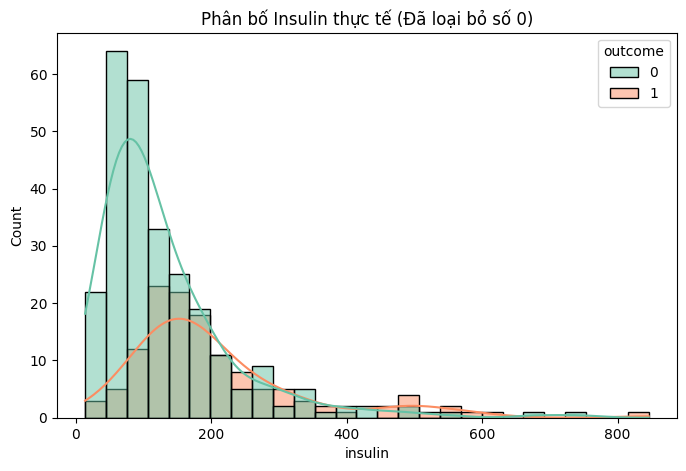

In [25]:
fig_clean, ax_clean = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=df_masked, 
    x="insulin", 
    hue="outcome", 
    kde=True, 
    ax=ax_clean,
    palette="Set2"
)
ax_clean.set_title("Phân bố Insulin thực tế (Đã loại bỏ số 0)")
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14440\1401781678.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


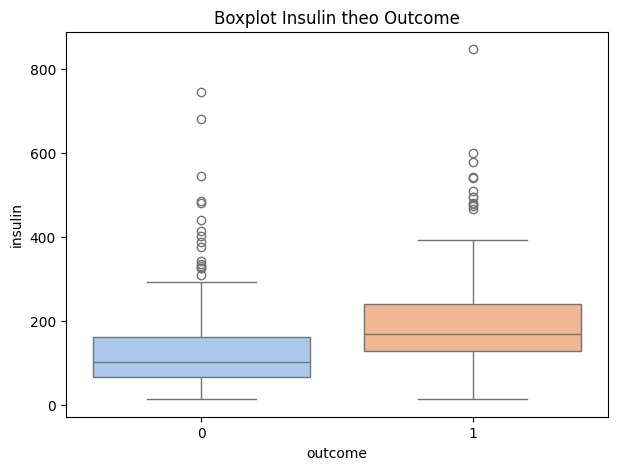

In [26]:
fig_box, ax_box = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=df_masked,
    x="outcome",
    y="insulin",
    ax=ax_box,
    palette="pastel"
)
ax_box.set_title("Boxplot Insulin theo Outcome")
plt.show()

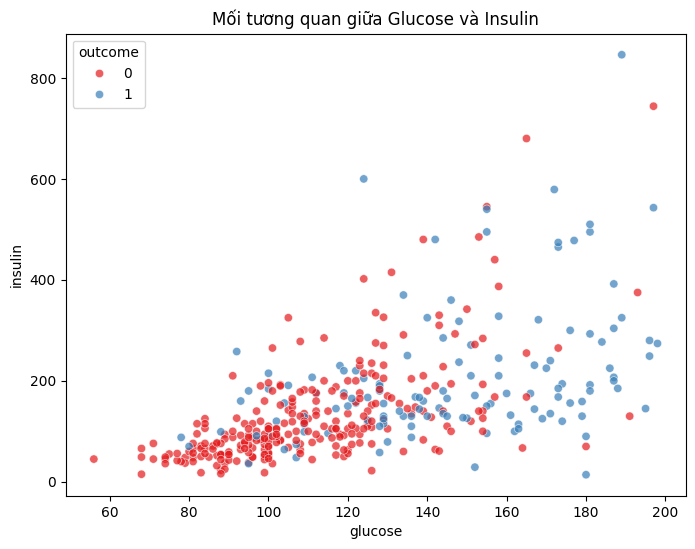

In [27]:
# Mối tương quan giữa Glucose và Insulin
fig_scatter, ax_scatter = plt.subplots(figsize=(8, 6))

# Ở đây chúng ta phải thay cả 0 thành NaN cho glucose để plot chính xác
plot_df = df_masked.copy()
plot_df['glucose'] = plot_df['glucose'].replace(0, float('nan'))

sns.scatterplot(
    data=plot_df,
    x="glucose",
    y="insulin",
    hue="outcome",
    alpha=0.7,
    ax=ax_scatter,
    palette="Set1"
)
ax_scatter.set_title("Mối tương quan giữa Glucose và Insulin")
plt.show()